# Gaussian summary-dimension source-mean LOWESS comparison

This plotting-only notebook places all four diagnostics in one 4 x 4 figure: rows are diagnostics and columns are assumed models. Color denotes summary dimension, not source dataset. Each source-model group contributes one diamond at its mean diagnostic/error location, and LOWESS is fitted **only to those source-mean diamonds**. The translucent raw-dataset markers do not enter the LOWESS fit. Panel limits include every finite observation without quantile truncation. Diagnostic x-axes use a symmetric-log scale, and Posterior MMD panels use a y-axis lower limit of -0.5.

The vertical green band is the diagnostic typical set; the horizontal green band is the common calibrated error-acceptance interval.

In [1]:
from IPython.display import Image, display
import pandas as pd

from benchmark.examples.gaussian.analysis.summary_dimension_mean_loess_comparison import (
    DEFAULT_MODELS,
    DEFAULT_OUTPUT_DIR,
    DIAGNOSTICS,
    ERROR_METRICS,
    run_mean_loess_comparison,
)

## Plot controls

The default four-model layout matches the supplied reference image. Set `NORMALIZED=True` to normalize each error. `X_SYMLOG_LINTHRESH` controls the linear region around zero on every diagnostic x-axis. `LOWESS_FRAC` controls smoothing across the 12 source-mean diamonds for each summary dimension; it never changes which raw datasets are plotted. Well-specified raw datasets use larger squares, and their source-mean diamonds are also enlarged.

In [2]:
MODELS = DEFAULT_MODELS
NORMALIZED = False
LOWESS_FRAC = 1
X_SYMLOG_LINTHRESH = 1.0

YSCALE = {
    "posterior_mmd": "linear",
    "log10_logml_error": "symlog",
    "pmp_error": "linear",
}
Y_SYMLOG_LINTHRESH = {
    "posterior_mmd": 0.1,
    "log10_logml_error": 1.0,
    "pmp_error": 0.1,
}

In [3]:
comparison = run_mean_loess_comparison(
    diagnostics=DIAGNOSTICS,
    error_metrics=ERROR_METRICS,
    models=MODELS,
    output_dir=DEFAULT_OUTPUT_DIR,
    normalized=NORMALIZED,
    lowess_frac=LOWESS_FRAC,
    x_symlog_linthresh=X_SYMLOG_LINTHRESH,
    yscale=YSCALE,
    y_symlog_linthresh=Y_SYMLOG_LINTHRESH,
)
pd.DataFrame(
    [
        (error_metric, str(path))
        for error_metric, path in comparison["paths"].items()
    ],
    columns=["error_metric", "path"],
)

,error_metric,path
0,posterior_mmd,/Users/yimingzang/Documents/Project/benchmark2...
1,log10_logml_error,/Users/yimingzang/Documents/Project/benchmark2...
2,pmp_error,/Users/yimingzang/Documents/Project/benchmark2...


## Posterior MMD

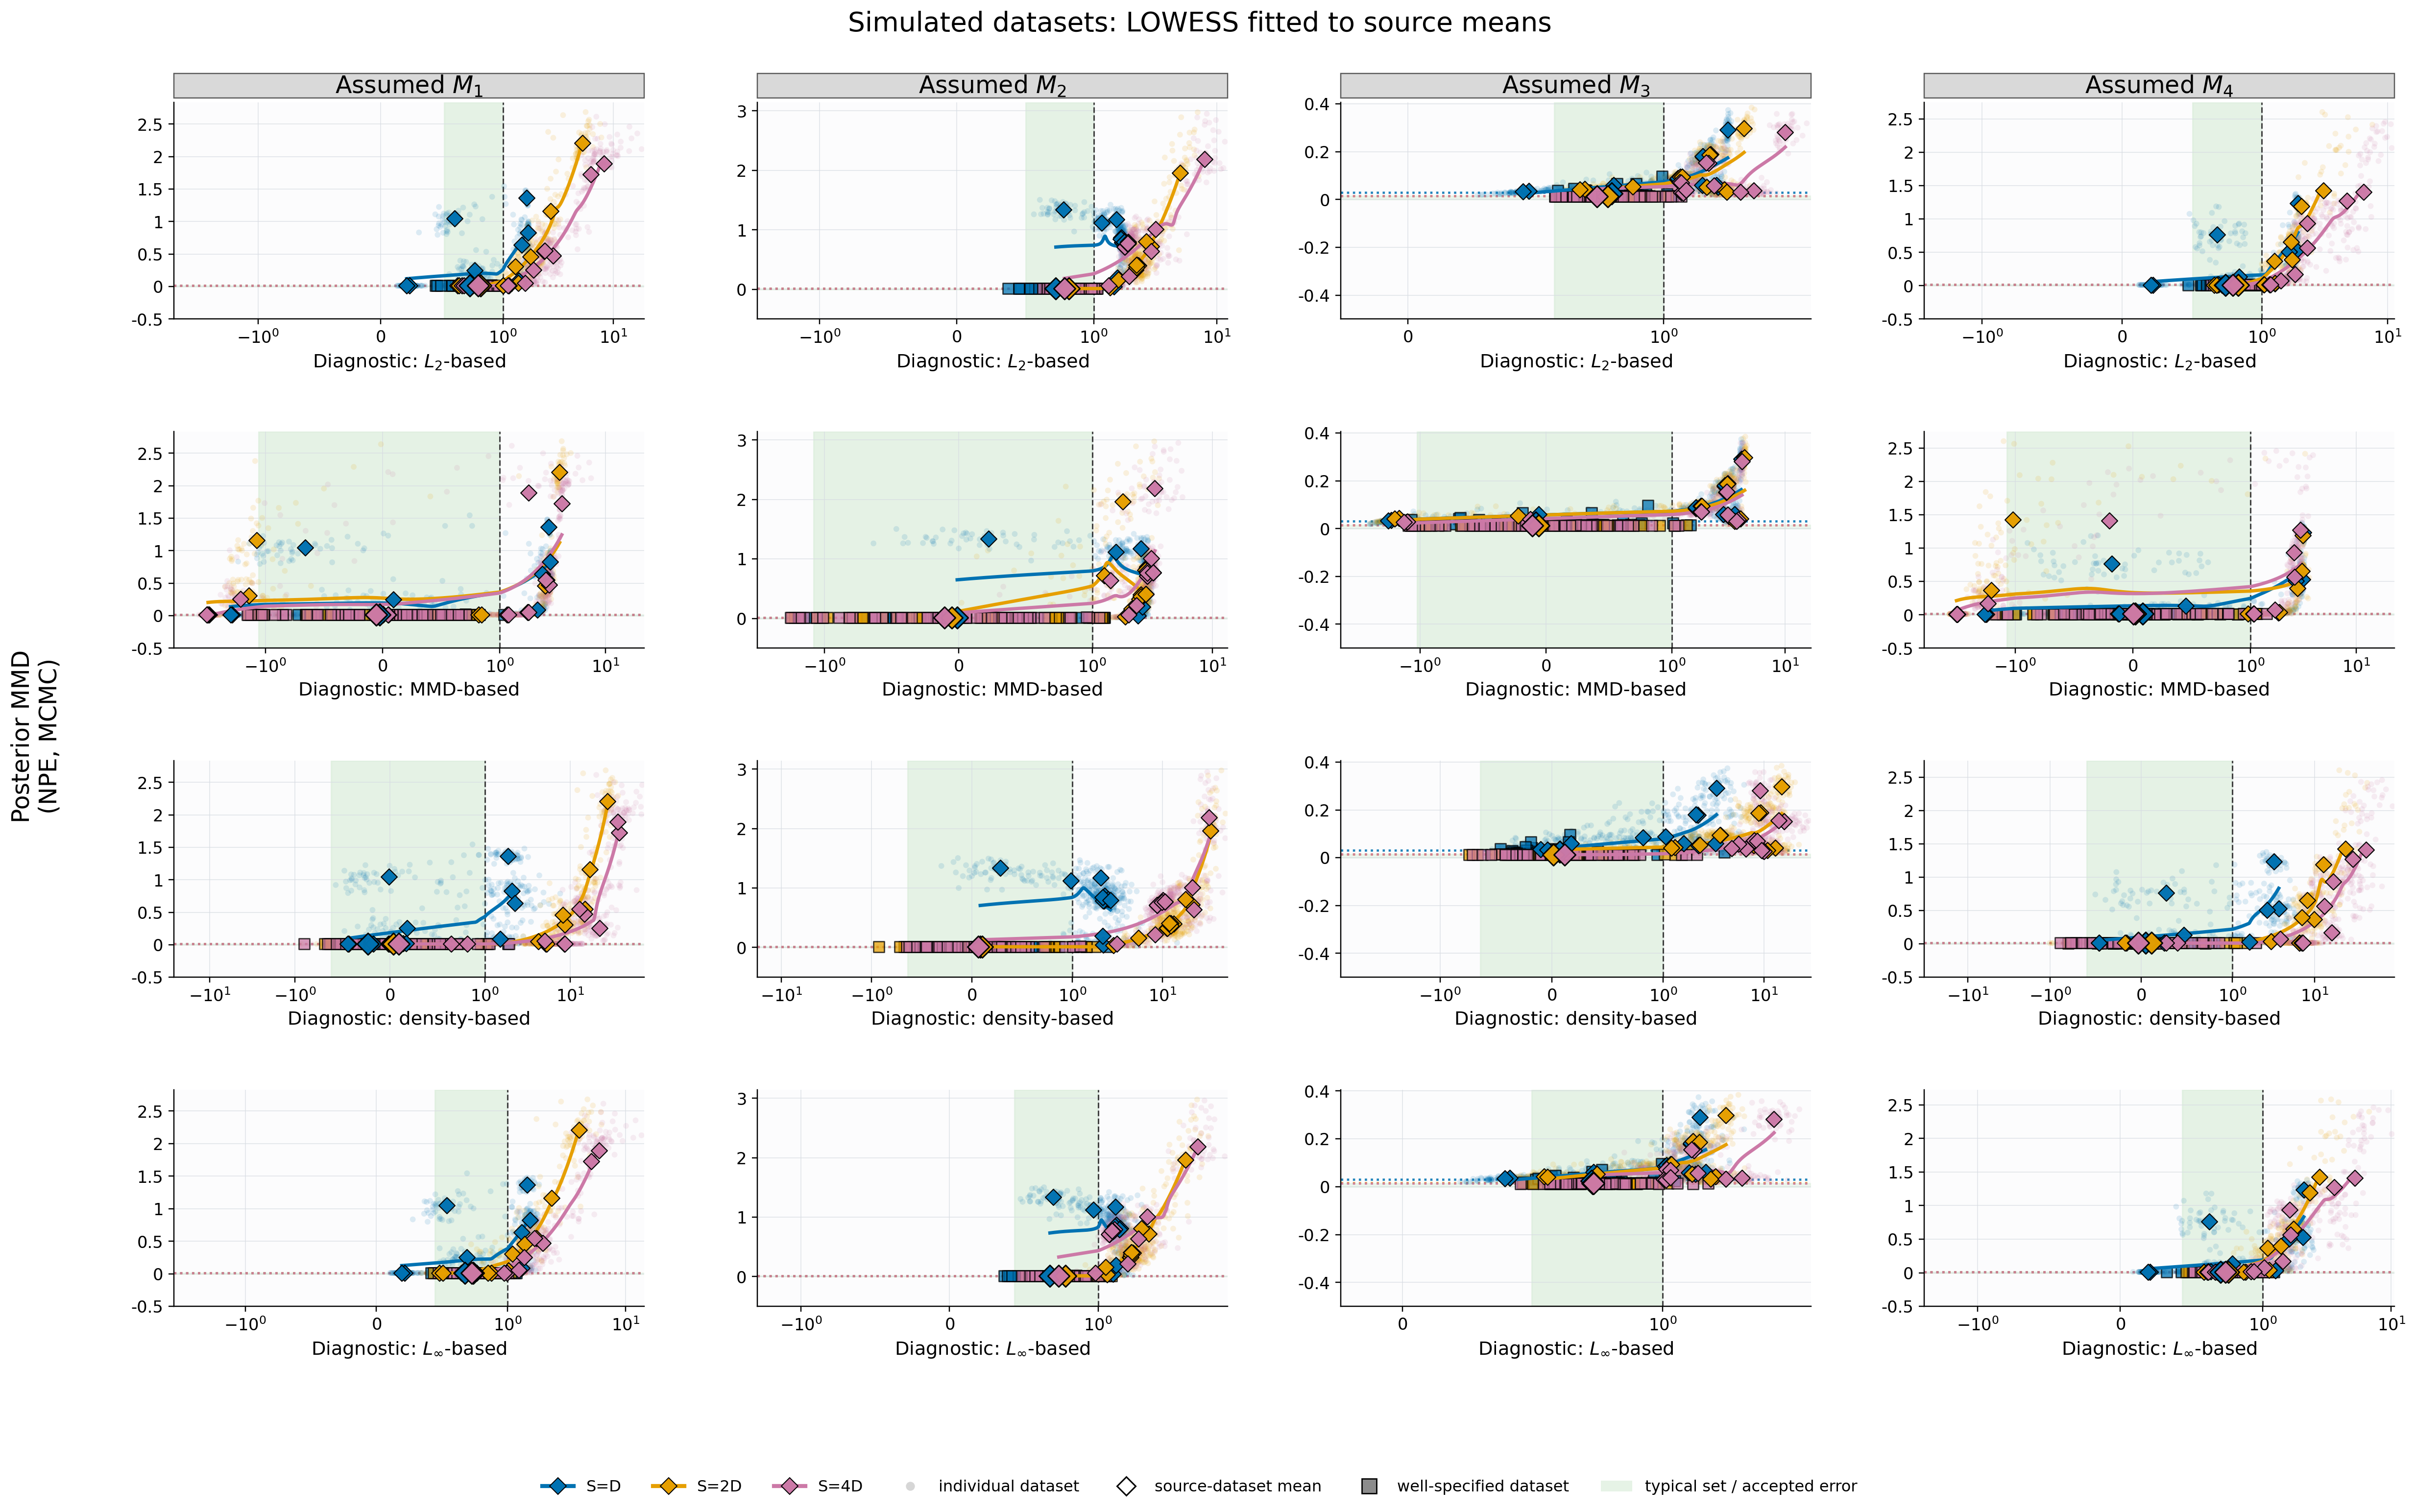

In [4]:
display(Image(filename=str(comparison["paths"]["posterior_mmd"])))

## Log10 marginal-likelihood error

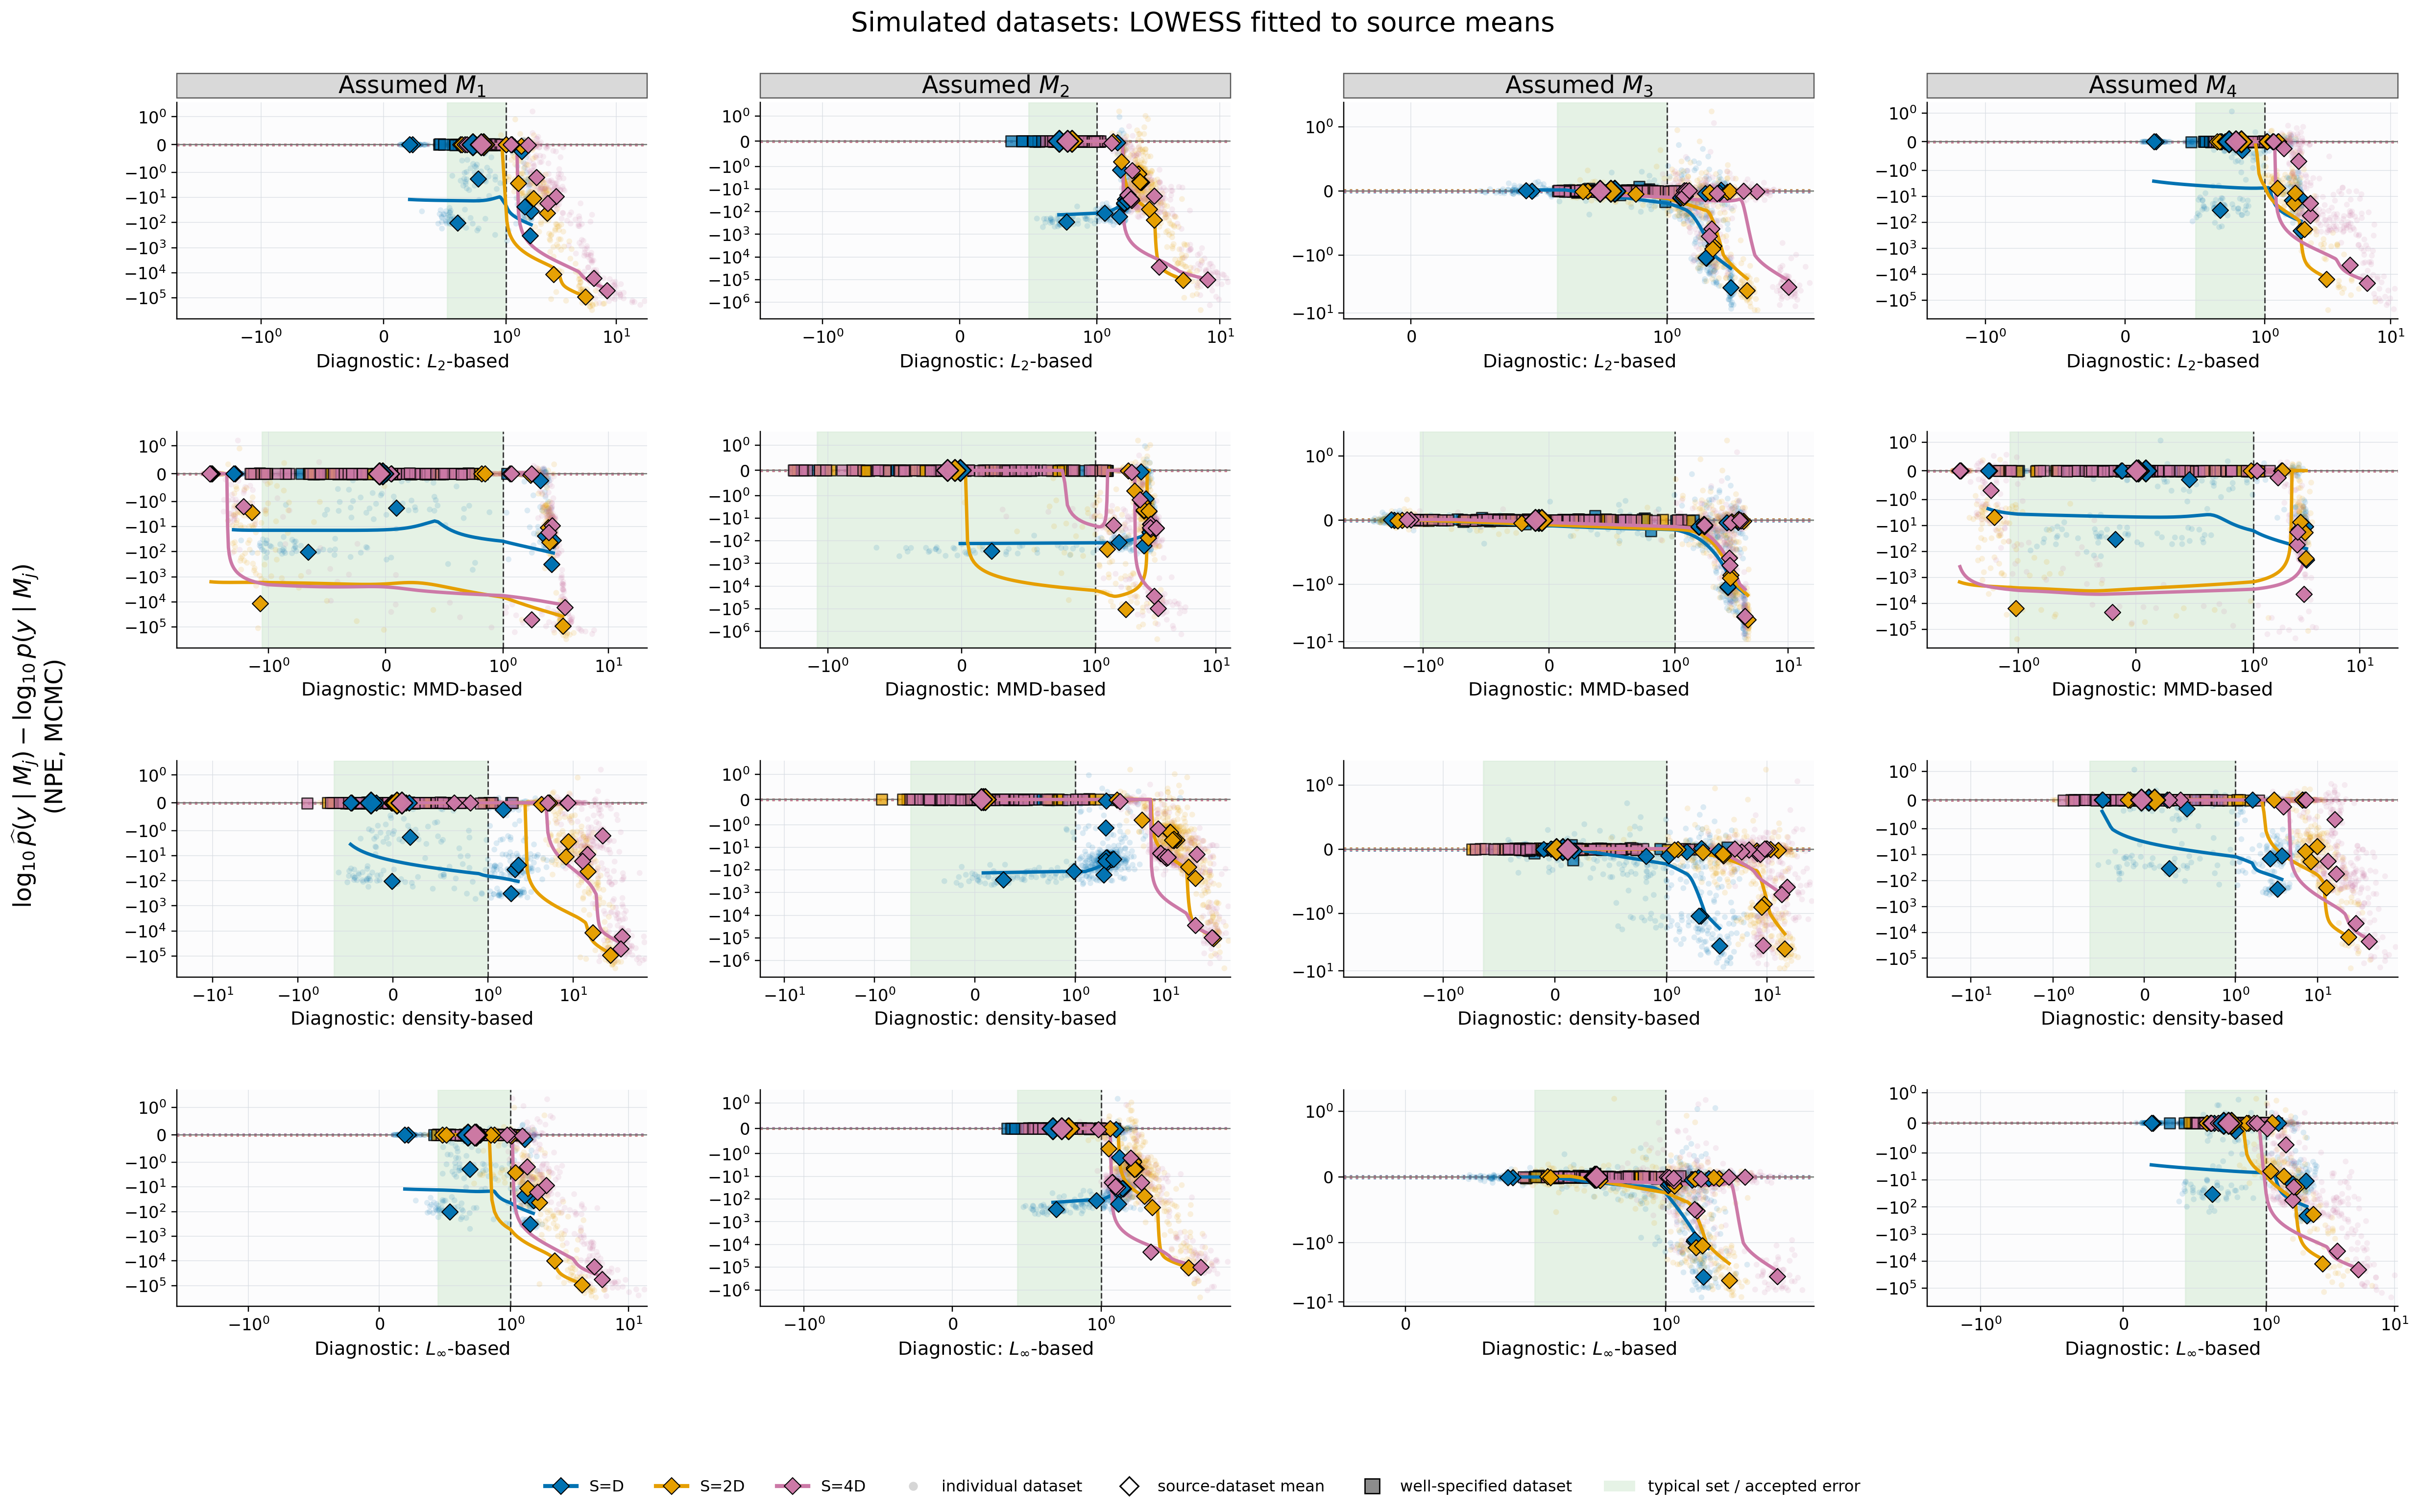

In [5]:
display(Image(filename=str(comparison["paths"]["log10_logml_error"])))

## PMP error

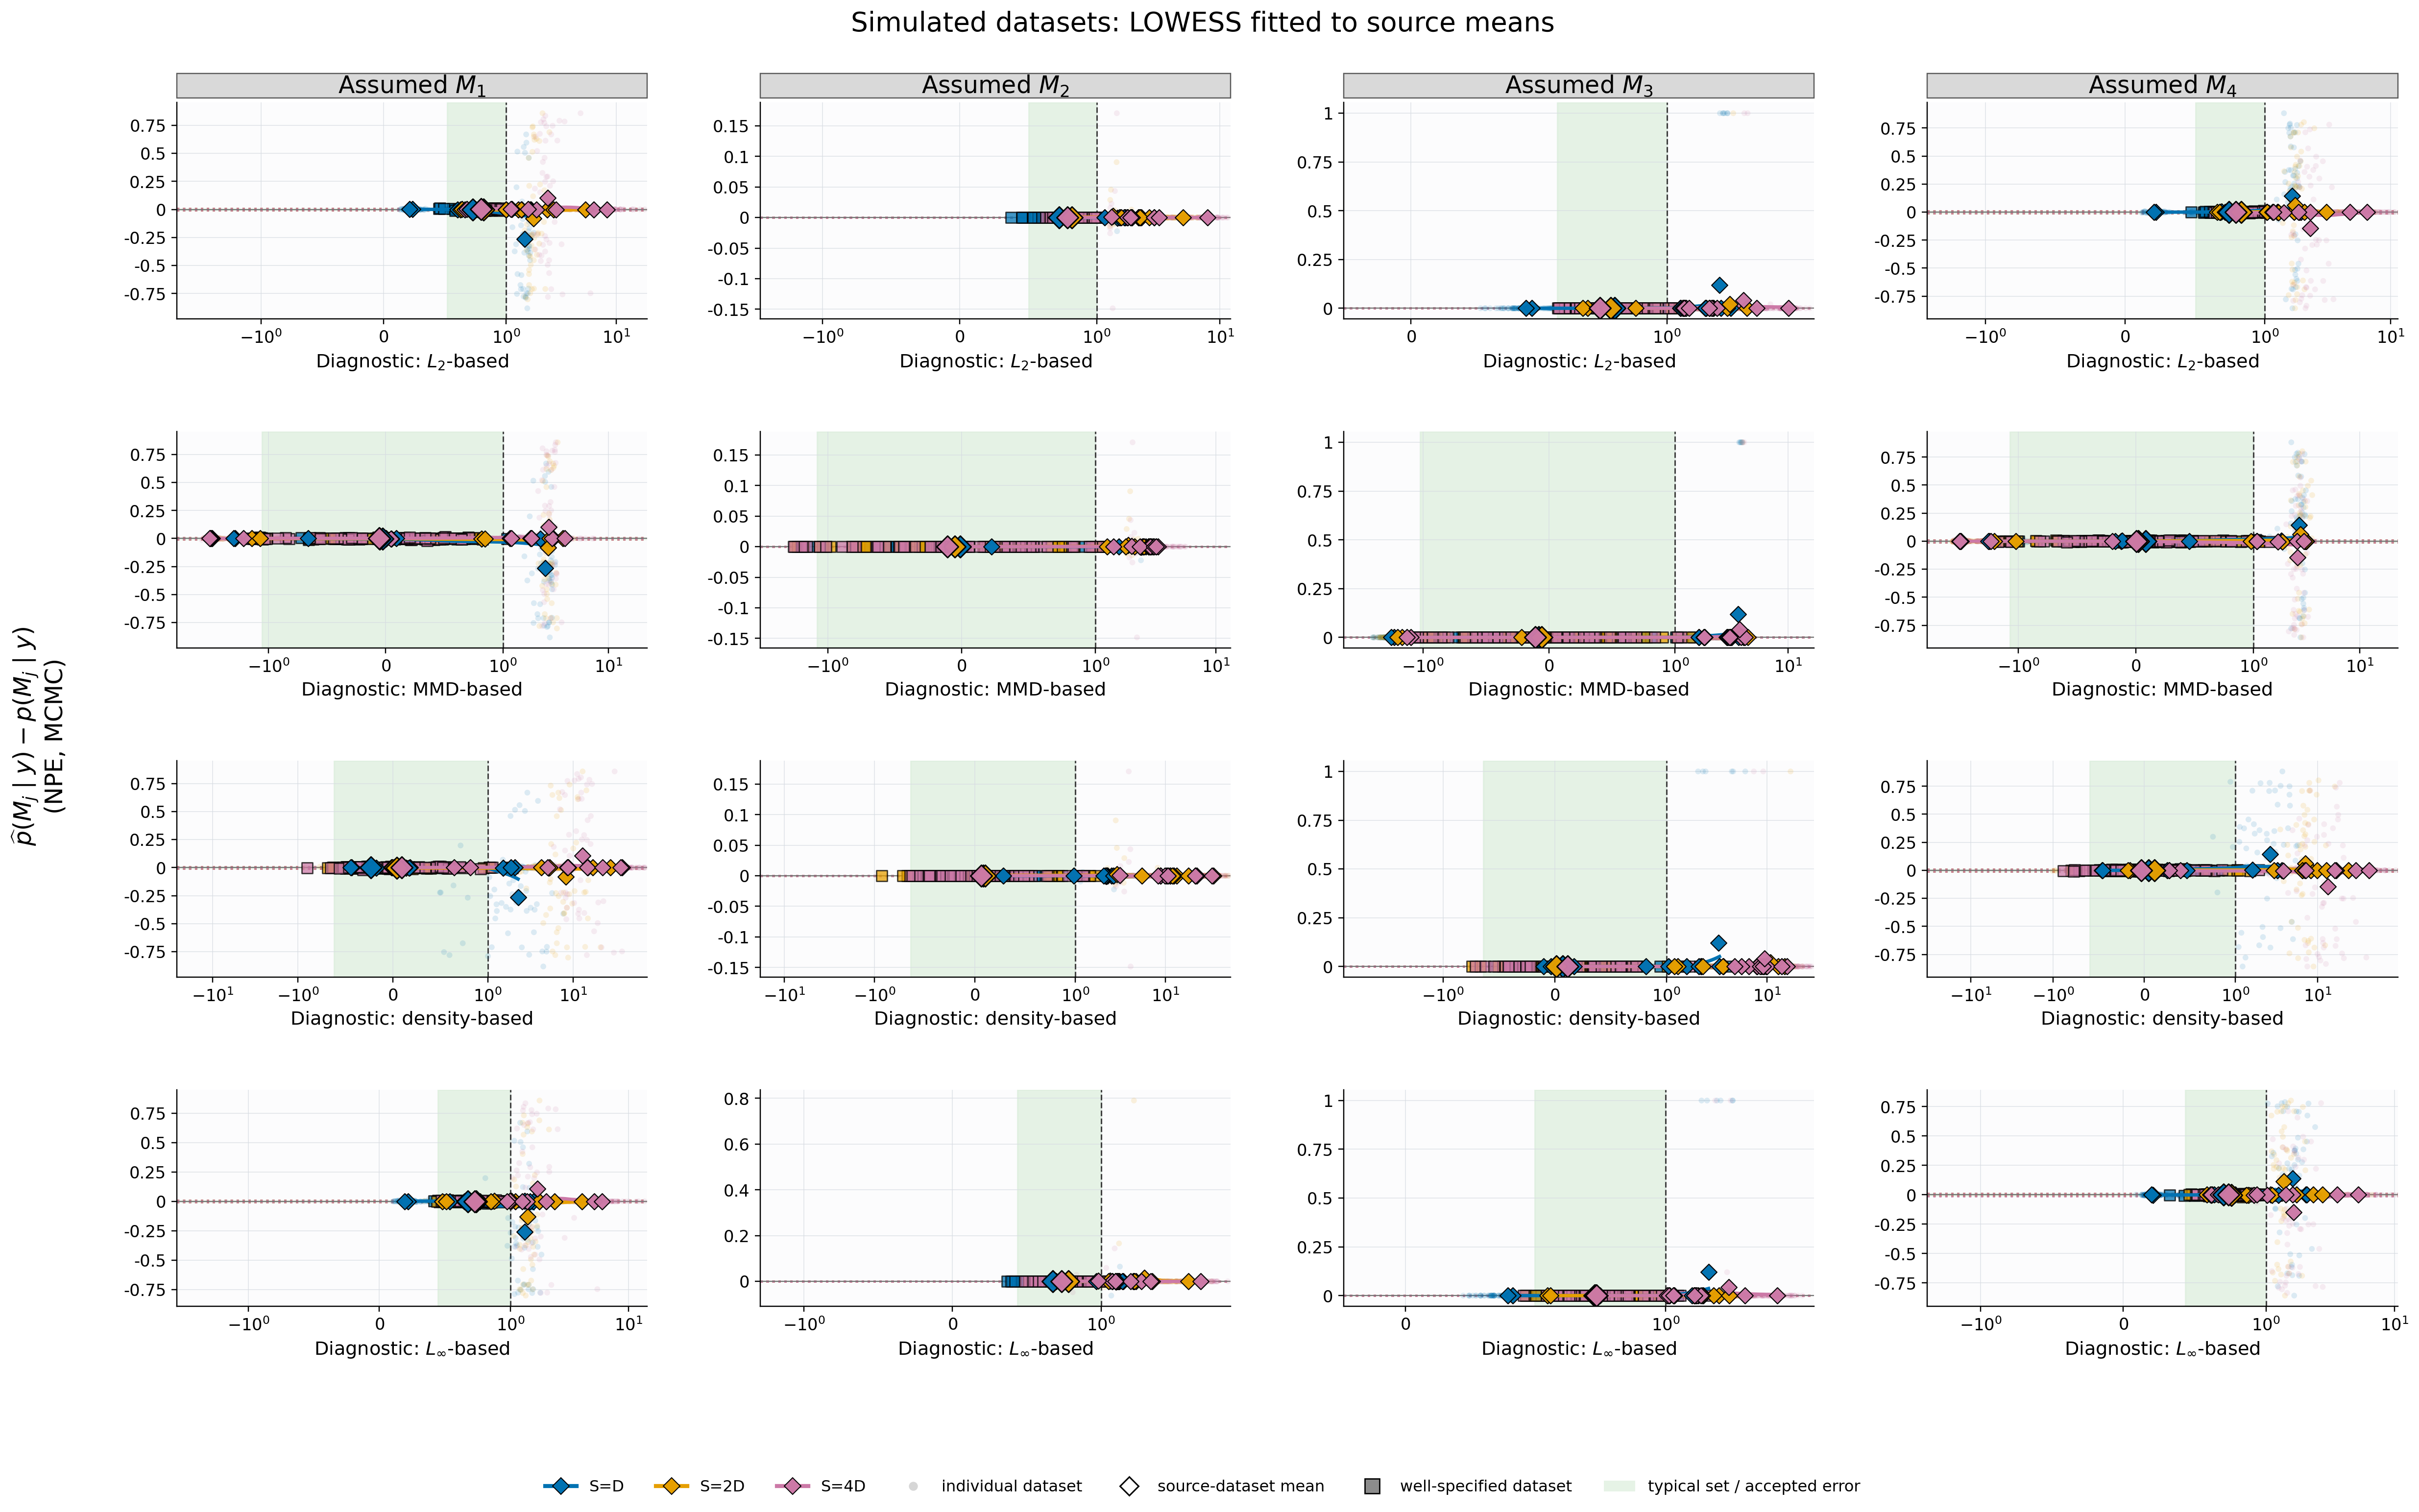

In [6]:
display(Image(filename=str(comparison["paths"]["pmp_error"])))